#### Objetivo: Encontrar método de identificar quando os dados param de agir de forma linear e vão se espalhando

In [8]:
# ---------------------
# Incluindo Bibliotecas
# ---------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VARMAX
from statsmodels.tsa.stattools import coint,kpss
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from itertools import product,combinations
import warnings

#### Funções auxiliares

In [ ]:
_EPS = 1e-12  # evita log10(0)

def _to_magnitude_db(df, real_col, imag_col):
    """Calcula magnitude em dB a partir de colunas real/imaginária."""
    mag = np.sqrt(df[real_col].values**2 + df[imag_col].values**2)
    return 20 * np.log10(np.clip(mag, _EPS, None))


def plot_magnitude_map(
    df_input,
    df_output,
    endog_cols=('Yreal', 'Yimg'),
    exog_cols=('Xreal', 'Ximg'),
    title="Mapa de Magnitude",
    save=False,
):
    mag_input_db  = _to_magnitude_db(df_input, exog_cols[0],  exog_cols[1])
    mag_output_db = _to_magnitude_db(df_output,  endog_cols[0], endog_cols[1])

    # Avisa se os tamanhos divergem antes de truncar
    if len(mag_input_db) != len(mag_output_db):
        warnings.warn(
            f"Tamanhos diferentes: input={len(mag_input_db)}, "
            f"output={len(mag_output_db)}. Truncando para o menor."
        )
    min_len = min(len(mag_input_db), len(mag_output_db))
    mag_input_db  = mag_input_db[:min_len]
    mag_output_db = mag_output_db[:min_len]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(mag_input_db, mag_output_db, marker='o', linestyle='-')
    ax.set_xlabel("MAG Input [dB]")
    ax.set_ylabel("MAG Output Forecast [dB]")
    ax.set_title(title)
    ax.grid(True)

    if save:
        img_label = title.replace(" ", "-").lower()
        fig.savefig(f"{img_label}.png", bbox_inches='tight')

    plt.show()
    plt.close(fig)  # libera memória

#### Leitura dos dataframes iniciais


In [10]:
data = "../data/dadosIniciais.xlsx"
data = pd.read_excel(data)

In [11]:
df_input = pd.DataFrame()
df_input["Xreal"] = data.iloc[:,0]
df_input["Ximg"] = data.iloc[:,1]

In [12]:
df_output = pd.DataFrame()
df_output["Yreal"] = data.iloc[:,2]
df_output["Yimg"] = data.iloc[:,3]

In [13]:
df_concat = pd.concat([df_output,df_input],axis=1)

#### Plotando Mapa de Magnitude

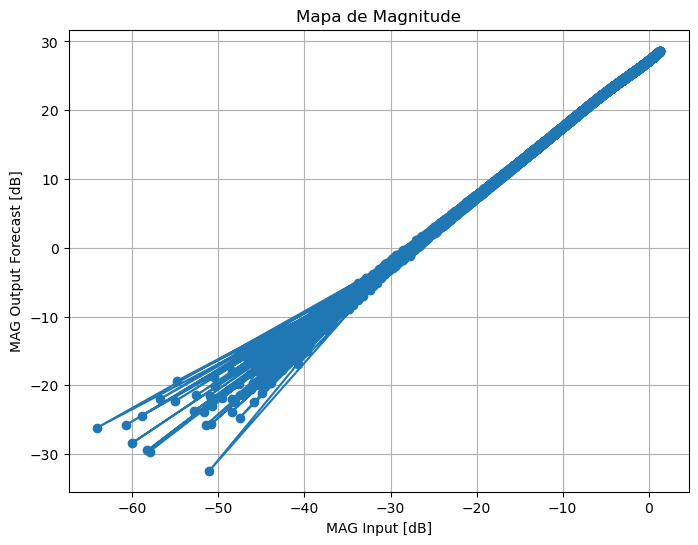

In [14]:
plot_magnitude_map(df_input,df_output)